# Paper Figures


Final figure generation for the ICML 2026 workshop submission.


In [1]:
from functools import cache
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from matplotlib.lines import Line2D
from wandb.apis.public.runs import Run

PROJECT = "graphcore/llama-mobile"
FIG_PATH = Path("/Users/lukar/Code/llama-mobile/figs")

# Set to True to save pdf figures to FIG_PATH
SAVE_FIGS = False

DOWNSTREAM_TASKS = ["vqa", "chartqa", "docvqa", "ai2d"]
TASK_TITLES = {
    "vqa": "VQA",
    "chartqa": "ChartQA",
    "docvqa": "DocVQA",
    "ai2d": "AI2D",
}


# Global plot parameters
COLORS = {
    "int_qat": "#4C78A8",
    "int_direct": "#8FB1D4",
    "s3d8": "#E45756",
    "bf16": "0.35",
}
POINT_SIZE = 60
DIRECT_POINT_SIZE = 70
STAR_SIZE = 180
POINT_ALPHA = 0.95
EDGE_WIDTH = 0.6
LINE_WIDTH = 1.1
GRID_STYLE = {"axis": "y", "linestyle": ":", "linewidth": 0.6, "alpha": 0.45}

LABELS = {
    "int": r"$\mathtt{INT}$ + block scaling",
    "int_qat": "    QAT",
    "int_direct": "    direct cast",
    "bf16": r"$\mathtt{bfloat16}$ baseline",
    "s3d8": r"$\mathtt{S3D8}$",
}

sns.set_theme(style="ticks", context="paper")
plt.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

In [2]:
api = wandb.Api()


In [3]:
# Data helpers
def get_metric(task: str) -> str:
    from eval.vqa import TASKS

    metrics = TASKS[task].METRICS
    assert len(metrics) == 1
    return metrics[0]


def overall_metric(scores: list[float]) -> float:
    return sum(scores) / len(scores)


def get_field(x: Any, key: str) -> Any:
    if isinstance(x, dict):
        return x.get(key)
    return getattr(x, key, None)


def activation_fmt_name(fmt: Any) -> str:
    if fmt is None:
        return "bf16"

    fmt_type = get_field(fmt, "_type")
    element_format = get_field(fmt, "element_format")
    if fmt_type == "int" or (
        fmt_type == "linear" and get_field(element_format, "_type") == "int"
    ):
        return "int"
    return str(fmt)


@cache
def get_num_params(model_name: str) -> int:
    from accelerate import init_empty_weights
    from transformers import AutoConfig, MllamaForConditionalGeneration

    config = AutoConfig.from_pretrained(model_name)
    with init_empty_weights():
        model = MllamaForConditionalGeneration(config)
    return sum(p.numel() for p in model.parameters())


def get_prompt_type(train_data: list[dict[str, Any]]) -> str:
    assert len(train_data) == 1
    prompt_path = train_data[0]["path"].split("/")[-1]
    if prompt_path == "single-prompt-1280k":
        return "fixed"
    if prompt_path == "new-prompts-1280k":
        return "sampled"
    raise ValueError(f"unexpected prompt path: {prompt_path}")


def quantisation_format_name(fmt: dict[str, Any]) -> str:
    fmt_type = fmt["_type"]
    if fmt_type == "linear":
        element_format = fmt["element_format"]
        if element_format["_type"] == "lut":
            df = int(element_format["name"].split("[")[1].split("]")[0])
            return f"student-t [df={df}]"
        return element_format["_type"]

    if fmt_type == "fit_scaled":
        if fmt["element_family"] == "t":
            return "student-t [fit]"
        if fmt["element_family"] == "s3d8":
            return "s3d8"

    raise ValueError(f"unexpected format type: {fmt_type}")


def cleanup_run(run: Run) -> dict[str, Any]:
    config = run.config
    scores = {
        task: run.summary[f"downstream.{task}.{get_metric(task)}"]
        for task in DOWNSTREAM_TASKS
    }
    history = run.history()

    return {
        "name": run.name,
        "size": config["n_bits"] / (8 * 10**6),
        "bits_per_param": config["n_bits"] / get_num_params(config["model_name"]),
        "n_steps": config["training"]["n_steps"],
        "prompt": get_prompt_type(config["data"]["train"]),
        "rotation": config["training"].get("rotate_text_residual"),
        "activation_fmt": activation_fmt_name(config["quantisation"].get("activation_fmt")),
        "fmt": quantisation_format_name(config["quantisation"]["fmt"]),
        "overall": overall_metric(list(scores.values())),
        "train_loss": history["train/loss"].tail(10).mean()
        if "train/loss" in history
        else None,
        "val_loss": run.summary.get("val/loss"),
        **scores,
    }


def load_runs(wandb_api: Any, config_name: str):
    return wandb_api.runs(
        PROJECT, filters={"config.name": config_name, "state": "finished"}
    )


def runs_dataframe(wandb_api: Any, config_name: str) -> pd.DataFrame:
    return (
        pd.DataFrame([cleanup_run(run) for run in load_runs(wandb_api, config_name)])
        .sort_values(["size", "overall"])
        .reset_index(drop=True)
    )


In [4]:
# Plot helpers
def finish_axis(ax, *, x_margin: float = 0.04, y_margin: float = 0.08) -> None:
    ax.grid(**GRID_STYLE)
    ax.margins(x=x_margin, y=y_margin)
    sns.despine(ax=ax)


def add_bits_axis(ax, size_to_bpp: float):
    secax = ax.secondary_xaxis(
        "top",
        functions=(lambda size: size * size_to_bpp, lambda bpp: bpp / size_to_bpp),
    )
    secax.set_xlabel("Bits per parameter", color="0.4", labelpad=5)
    secax.tick_params(axis="x", colors="0.45", labelsize=8, pad=2)
    secax.spines["top"].set_color("0.6")
    secax.spines["top"].set_alpha(0.5)
    return secax


def finish_size_axis(ax, size_to_bpp: float, **kwargs: Any) -> None:
    finish_axis(ax, **kwargs)
    add_bits_axis(ax, size_to_bpp)


def plot_int_runs(ax, df: pd.DataFrame, y: str, *, direct: bool = False) -> None:
    if df.empty:
        return

    if direct:
        ax.scatter(
            df["size"],
            df[y],
            s=DIRECT_POINT_SIZE,
            marker="x",
            color=COLORS["int_direct"],
            linewidth=1.2,
            alpha=POINT_ALPHA,
            zorder=4,
        )
        return

    ax.scatter(
        df["size"],
        df[y],
        s=POINT_SIZE,
        color=COLORS["int_qat"],
        edgecolor="white",
        linewidth=EDGE_WIDTH,
        alpha=POINT_ALPHA,
        zorder=3,
    )


def plot_bf16(ax, y: float) -> None:
    ax.axhline(y, linestyle="--", linewidth=LINE_WIDTH, color=COLORS["bf16"])


def plot_s3d8(ax, x: float, y: float) -> None:
    ax.scatter(
        [x],
        [y],
        marker="*",
        s=STAR_SIZE,
        color=COLORS["s3d8"],
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )


def plot_prompt_groups(
    ax,
    groups: dict[str, pd.DataFrame],
    styles: dict[str, dict[str, Any]],
    y: str,
    *,
    label: bool = False,
) -> None:
    for prompt_type, df in groups.items():
        if df.empty:
            continue

        style = styles[prompt_type]
        ax.scatter(
            df["n_steps"],
            df[y],
            s=POINT_SIZE,
            marker=style["marker"],
            color=style["color"],
            edgecolor="white",
            linewidth=EDGE_WIDTH,
            alpha=POINT_ALPHA,
            zorder=3,
            label=style["label"] if label else None,
        )


def model_legend_handles(*, compact: bool = False) -> list[Line2D]:
    handles = [
        Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            markersize=6,
            markerfacecolor=COLORS["int_qat"],
            markeredgecolor="white",
            markeredgewidth=EDGE_WIDTH,
            label=LABELS["int_qat"] if not compact else LABELS["int"] + " (QAT)",
        ),
        Line2D(
            [],
            [],
            marker="x",
            linestyle="",
            markersize=7,
            color=COLORS["int_direct"],
            markeredgewidth=1.2,
            label=LABELS["int_direct"] if not compact else LABELS["int"] + " (direct cast)",
        ),
        Line2D(
            [],
            [],
            marker="*",
            linestyle="",
            markersize=10,
            color=COLORS["s3d8"],
            markeredgecolor="black",
            label=LABELS["s3d8"],
        ),
        Line2D(
            [],
            [],
            linestyle="--",
            linewidth=LINE_WIDTH,
            color=COLORS["bf16"],
            label=LABELS["bf16"],
        ),
    ]
    if compact:
        return handles
    return [Line2D([], [], linestyle="", marker="", color="none", label=LABELS["int"]), *handles[:2], handles[-1]]


def prompt_legend_handles(styles: dict[str, dict[str, Any]]) -> list[Line2D]:
    return [
        Line2D(
            [],
            [],
            marker=style["marker"],
            linestyle="",
            markersize=6,
            markerfacecolor=style["color"],
            markeredgecolor="white",
            markeredgewidth=EDGE_WIDTH,
            label=style["label"],
        )
        for style in styles.values()
    ]


def save_figure(fig, filename: str) -> None:
    if SAVE_FIGS:
        fig.savefig(FIG_PATH / filename, bbox_inches="tight")


In [5]:
int_baseline_run = "int-baseline-22-04-26"
s3d8_run = "new-fmt-21-04-26"

baseline_df = runs_dataframe(api, int_baseline_run)
df_new = runs_dataframe(api, s3d8_run)

display(baseline_df.sort_values("size"))
display(df_new.sort_values(["size", "overall"]))


,name,size,bits_per_param,n_steps,prompt,rotation,activation_fmt,fmt,overall,train_loss,val_loss,vqa,chartqa,docvqa,ai2d
0,balmy-donkey-1901,2840.533430,2.129690,2048,sampled,False,int,int,0.000000,0.808444,1.248574,0.000000,0.000000,0.000000,0.000000
1,floral-waterfall-1907,2840.533430,2.129690,0,sampled,False,int,int,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
2,noble-firefly-1900,3007.199270,2.254648,2048,sampled,False,int,int,0.000000,0.737050,1.146234,0.000000,0.000000,0.000000,0.000000
3,denim-wave-1918,3007.199270,2.254648,0,sampled,False,int,int,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
4,serene-sound-1903,3340.530950,2.504564,2048,sampled,False,int,int,0.000163,0.524068,0.850739,0.000651,0.000000,0.000000,0.000000
5,solar-brook-1906,3340.530950,2.504564,0,sampled,False,int,int,0.000326,NaN,NaN,0.001302,0.000000,0.000000,0.000000
6,easy-surf-1913,3620.479562,2.714455,0,sampled,False,int,int,0.000895,NaN,NaN,0.003581,0.000000,0.000000,0.000000
7,happy-planet-1894,3620.479562,2.714455,2048,sampled,False,int,int,0.347019,0.086261,0.145117,0.578776,0.302734,0.257542,0.249023
8,copper-plant-1915,3787.145402,2.839413,0,sampled,False,int,int,0.001221,NaN,NaN,0.004883,0.000000,0.000000,0.000000
9,giddy-frog-1892,3787.145402,2.839413,2048,sampled,False,int,int,0.360903,0.072365,0.120874,0.572917,0.453125,0.256439,0.161133


,name,size,bits_per_param,n_steps,prompt,rotation,activation_fmt,fmt,overall,train_loss,val_loss,vqa,chartqa,docvqa,ai2d
0,brisk-serenity-1985,3568.774604,2.675689,0,sampled,True,int,s3d8,0.000081,NaN,NaN,0.000326,0.000000,0.000000,0.000000
1,super-star-1930,3568.774604,2.675689,0,sampled,False,int,s3d8,0.001383,NaN,NaN,0.005534,0.000000,0.000000,0.000000
2,toasty-jazz-1876,3568.774604,2.675689,2048,sampled,True,bf16,s3d8,0.534913,0.036170,0.076068,0.675781,0.643555,0.613286,0.207031
3,twilight-plant-1984,3568.774604,2.675689,2048,sampled,True,int,s3d8,0.598031,0.041253,0.080395,0.666341,0.638672,0.502150,0.584961
4,icy-shadow-1888,3568.774604,2.675689,4096,sampled,False,int,s3d8,0.658020,0.034126,0.072855,0.678385,0.658203,0.698810,0.596680
5,proud-sponge-1878,3568.774604,2.675689,2048,sampled,False,int,s3d8,0.661143,0.041032,0.077134,0.702148,0.648438,0.740275,0.553711
6,spring-rain-1874,3568.774604,2.675689,2048,sampled,False,bf16,s3d8,0.689572,0.035088,0.061787,0.703776,0.680664,0.751777,0.622070
7,light-cloud-1873,3918.998892,2.938270,2048,sampled,True,int,s3d8,0.618559,0.038982,0.078631,0.676758,0.631836,0.628531,0.537109
8,charmed-voice-1986,3918.998892,2.938270,2048,sampled,False,int,s3d8,0.660875,0.040128,0.073240,0.689128,0.668945,0.751247,0.534180
9,devoted-valley-1880,4163.096140,3.121282,2048,sampled,True,int,s3d8,0.545325,0.035914,0.087430,0.632161,0.686523,0.412418,0.450195


In [6]:
best_s3d8_run = "proud-sponge-1878"

best_run = df_new.loc[df_new["name"] == best_s3d8_run].iloc[0]
display(best_run)


name              proud-sponge-1878
size                    3568.774604
bits_per_param             2.675689
n_steps                        2048
prompt                      sampled
rotation                      False
activation_fmt                  int
fmt                            s3d8
overall                    0.661143
train_loss                 0.041032
val_loss                   0.077134
vqa                        0.702148
chartqa                    0.648438
docvqa                     0.740275
ai2d                       0.553711
Name: 5, dtype: object

In [7]:
bf16_run_name = "whole-fire-1607"

bf16_run = api.runs(
    PROJECT,
    filters={"display_name": bf16_run_name, "state": "finished"},
)[0]

baseline = {
    task: bf16_run.summary[f"downstream.{task}.{get_metric(task)}"]
    for task in DOWNSTREAM_TASKS
}
baseline["overall"] = overall_metric(list(baseline.values()))
baseline_size = bf16_run.config["n_bits"] / (8 * 10**6)

display(baseline)
print(f"Original size: {baseline_size:.0f} MB")


{'vqa': 0.7542318105697632,
 'chartqa': 0.7470703125,
 'docvqa': 0.8444538116455078,
 'ai2d': 0.630859375,
 'overall': 0.7441538274288177}

Original size: 21340 MB


In [8]:
qat_df = baseline_df.loc[baseline_df["n_steps"] == 2048]
direct_cast_df = baseline_df.loc[baseline_df["n_steps"] == 0]
other_int_df = baseline_df.loc[~baseline_df["n_steps"].isin([0, 2048])]

our_size = best_run["size"]
our_perf = best_run["overall"]
our_task_scores = best_run[DOWNSTREAM_TASKS].to_dict()
our_loss_scores = best_run[["train_loss", "val_loss"]].to_dict()
size_to_bpp = baseline_df["bits_per_param"].iloc[0] / baseline_df["size"].iloc[0]


### Main Figure

Compare INT block-scaled baselines against the selected S3D8 run. Baseline points use INT activations, no rotations, and either direct casting or 2k-step QAT.

Runs:
- INT baseline: `int-baseline-22-04-26`
- S3D8: `new-fmt-21-04-26`
- bfloat16 reference: `whole-fire-1607`

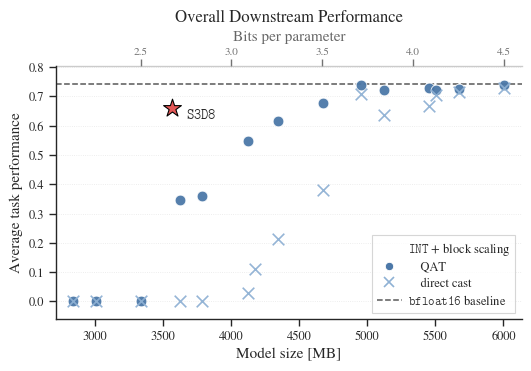

In [9]:
figsize = (5.2, 3.6)
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

for df, direct in [(qat_df, False), (other_int_df, False), (direct_cast_df, True)]:
    plot_int_runs(ax, df, "overall", direct=direct)
plot_bf16(ax, baseline["overall"])
plot_s3d8(ax, our_size, our_perf)

ax.annotate(
    LABELS["s3d8"],
    xy=(our_size, our_perf),
    xytext=(10, -10),
    textcoords="offset points",
    fontsize=10,
    ha="left",
    va="bottom",
)
ax.set(
    title="Overall Downstream Performance",
    xlabel="Model size [MB]",
    ylabel="Average task performance",
)
finish_size_axis(ax, size_to_bpp)

ax.legend(
    handles=model_legend_handles(),
    loc="lower right",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig1.pdf")
plt.show()


### Downstream Tasks


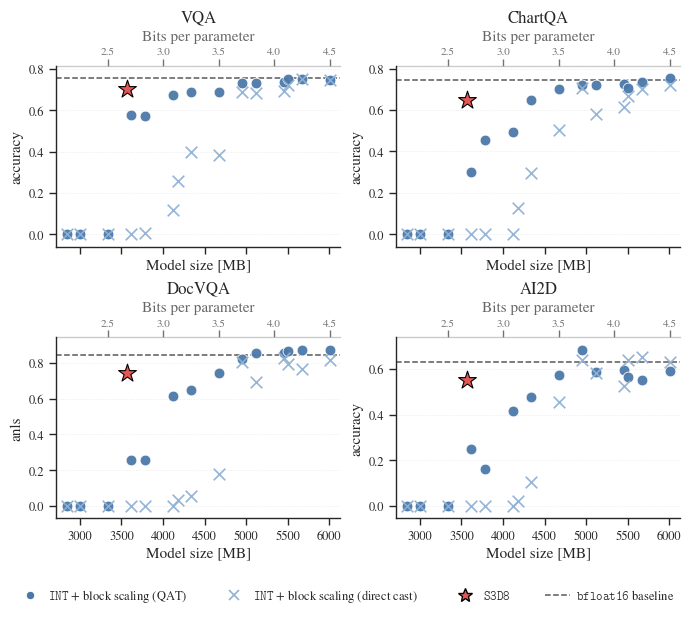

In [10]:
figsize = (6.8, 5.6)
fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, constrained_layout=True)

for ax, task in zip(axes.flatten(), DOWNSTREAM_TASKS):
    for df, direct in [(qat_df, False), (other_int_df, False), (direct_cast_df, True)]:
        plot_int_runs(ax, df, task, direct=direct)
    plot_bf16(ax, baseline[task])
    plot_s3d8(ax, our_size, our_task_scores[task])

    ax.set(title=TASK_TITLES[task], xlabel="Model size [MB]", ylabel=get_metric(task))
    finish_size_axis(ax, size_to_bpp)

fig.legend(
    handles=model_legend_handles(compact=True),
    loc="lower center",
    ncol=4,
    mode="expand",
    frameon=False,
    bbox_to_anchor=(0.0, -0.09, 1.0, 0.08),
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig_tasks.pdf")
plt.show()


### Loss Curves


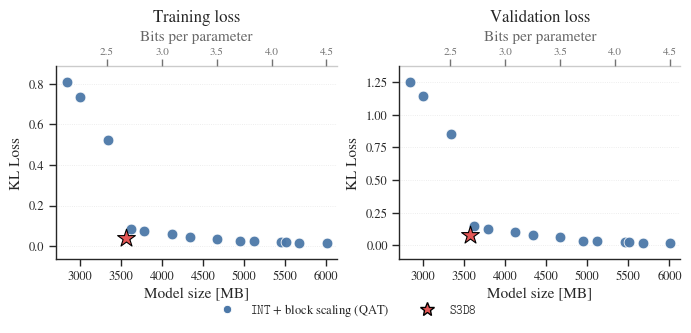

In [11]:
loss_specs = [("train_loss", "Training loss"), ("val_loss", "Validation loss")]
figsize = (6.8, 3.0)
fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

for ax, (key, title) in zip(axes, loss_specs):
    plot_int_runs(ax, baseline_df.dropna(subset=[key]), key)
    plot_s3d8(ax, our_size, our_loss_scores[key])

    ax.set(title=title, xlabel="Model size [MB]", ylabel="KL Loss")
    finish_size_axis(ax, size_to_bpp, y_margin=0.10)

fig.legend(
    handles=model_legend_handles(compact=True)[::2],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

save_figure(fig, "fig_loss.pdf")
plt.show()


### Prompt Sampling vs. Fixed Prompt


Compare sampled prompts against a fixed `Describe this image` prompt. Both settings use the same 75% instruction-template mix, INT3 weights with 64-value block scales, and steps in `[256, 512, 1024, 2048]`.

Run: `prompt-comparison-24-04-26`


In [12]:
prompt_run = "prompt-comparison-24-04-26"
prompt_styles = {
    "sampled": {"color": COLORS["int_qat"], "marker": "o", "label": "Sampled"},
    "fixed": {"color": COLORS["s3d8"], "marker": "s", "label": "Fixed"},
}

prompt_df = runs_dataframe(api, prompt_run)
prompt_groups = {
    prompt_type: prompt_df.loc[prompt_df["prompt"] == prompt_type].sort_values("n_steps")
    for prompt_type in prompt_styles
}
prompt_steps = sorted(prompt_df["n_steps"].unique())

display(prompt_df)


,name,size,bits_per_param,n_steps,prompt,rotation,activation_fmt,fmt,overall,train_loss,val_loss,vqa,chartqa,docvqa,ai2d
0,ethereal-water-1982,4340.52599,3.25431,1024,fixed,False,int,int,0.213155,0.049401,0.109742,0.344401,0.366211,0.090249,0.051758
1,solar-wildflower-1978,4340.52599,3.25431,256,fixed,False,int,int,0.215733,0.076681,0.142208,0.398763,0.170898,0.183895,0.109375
2,rare-bee-1981,4340.52599,3.25431,512,fixed,False,int,int,0.254703,0.061844,0.122064,0.414388,0.228516,0.172784,0.203125
3,dandy-paper-1978,4340.52599,3.25431,2048,fixed,False,int,int,0.335963,0.039983,0.088989,0.437500,0.549805,0.098734,0.257812
4,electric-sea-1991,4340.52599,3.25431,4096,fixed,False,int,int,0.378364,0.033112,0.077648,0.455729,0.547852,0.102647,0.407227
5,royal-wave-1983,4340.52599,3.25431,512,sampled,False,int,int,0.402382,0.066791,0.098409,0.651693,0.581055,0.263499,0.113281
6,vibrant-cloud-1976,4340.52599,3.25431,256,sampled,False,int,int,0.439071,0.084920,0.117811,0.639974,0.542969,0.477637,0.095703
7,worthy-violet-1980,4340.52599,3.25431,1024,sampled,False,int,int,0.500261,0.050930,0.080393,0.670573,0.684570,0.410549,0.235352
8,twilight-music-1977,4340.52599,3.25431,2048,sampled,False,int,int,0.607821,0.042415,0.073916,0.687826,0.665039,0.671194,0.407227
9,sunny-cosmos-1989,4340.52599,3.25431,4096,sampled,False,int,int,0.617043,0.035401,0.069891,0.684245,0.631836,0.674551,0.477539


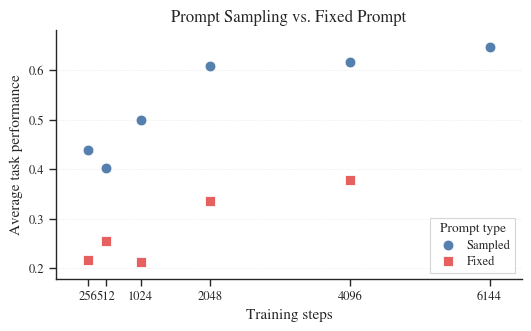

In [13]:
figsize = (5.2, 3.2)
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

plot_prompt_groups(ax, prompt_groups, prompt_styles, "overall", label=True)
ax.set(
    title="Prompt Sampling vs. Fixed Prompt",
    xlabel="Training steps",
    ylabel="Average task performance",
    xticks=prompt_steps,
)
finish_axis(ax, x_margin=0.08)

ax.legend(
    title="Prompt type",
    loc="lower right",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig_prompt_overall.pdf")
plt.show()


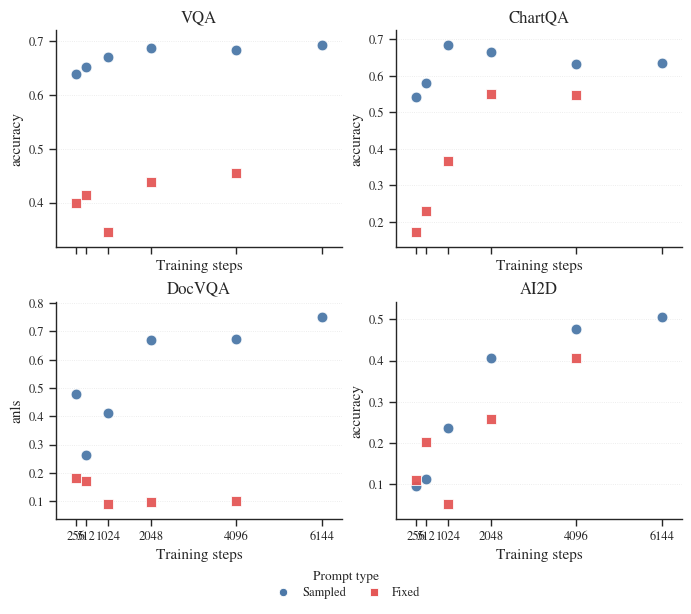

In [14]:
figsize = (6.8, 5.6)
fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, constrained_layout=True)

for ax, task in zip(axes.flatten(), DOWNSTREAM_TASKS):
    plot_prompt_groups(ax, prompt_groups, prompt_styles, task)
    ax.set(
        title=TASK_TITLES[task],
        xlabel="Training steps",
        ylabel=get_metric(task),
        xticks=prompt_steps,
    )
    finish_axis(ax, x_margin=0.08)

fig.legend(
    handles=prompt_legend_handles(prompt_styles),
    title="Prompt type",
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    columnspacing=1.2,
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig_prompt_tasks.pdf")
plt.show()
